---

<div style="background-color: #f8f9fa; padding: 25px; border-radius: 15px; border: 1px solid #e9ecef; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <div style="display: flex; align-items: center; gap: 20px;">
        <div style="flex: 1;">
            <h1 style="color: #2c3e50; margin: 0; font-size: 28px;">👨‍💻 Hemant Sharma</h1>
            <p style="color: #3498db; font-size: 18px; margin: 5px 0; font-weight: 600;">Computer Science & Engineering Student | PIET</p>
            <hr style="border: 0; border-top: 2px solid #3498db; width: 50px; margin: 15px 0;">
            <p style="color: #576574; line-height: 1.6; font-size: 15px;">
                I am a <b>CSE Student</b> at Poornima Institute of Engineering and Technology, focused on
                <b>Machine Learning</b> and <b>Artificial Intelligence</b>. This project is a detailed
                exploration into building <b>Neural Architectures</b> from scratch, emphasizing the
                mathematical foundations and optimization logic of Deep Learning.
            </p>
            <div style="margin-top: 20px;">
                <span style="background: #e1f5fe; color: #039be5; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 5px;">#MachineLearning</span>
                <span style="background: #f3e5f5; color: #8e24aa; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 5px;">#NeuralNetworks</span>
                <span style="background: #e8f5e9; color: #2e7d32; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold;">#AIDeveloper</span>
            </div>
        </div>
    </div>
    <div style="margin-top: 20px; border-top: 1px solid #eee; padding-top: 15px; display: flex; gap: 20px;">
        <a href="mailto:artist.hks.dev@gmail.com" style="text-decoration: none; color: #2c3e50; font-size: 14px;">📧 <b>Email:</b> artist.hks.dev@gmail.com</a>
        <a href="https://www.linkedin.com/in/artisthks" target="_blank" style="text-decoration: none; color: #2c3e50; font-size: 14px;">🔗 <b>LinkedIn:</b> artisthks</a>
    </div>
</div>

---

# <p style="color:#2c3e50; font-family:sans-serif; text-align:center; font-size:38px; font-weight:bold;">🚀 Project: Neural Networks from First Principles</p>
### <p style="text-align:center; color:#34495e; font-size:18px;">Implementation of Deep Learning Architecture using Pure NumPy</p>

---

## 🎯 Aim
To architect and train a fully connected Neural Network from scratch to solve the **non-linear XOR problem**, understanding the fundamental mechanics of Forward Propagation, Activation Functions, and Backpropagation via Calculus.

## 📚 Core Theory
A Neural Network is a mathematical function that maps inputs to outputs through a series of transformations.
- **The Linear Layer:** $Z = W \cdot A + b$ (Weighted sum)
- **The Non-linear Layer:** Applying an activation function to break linearity.
- **The Learning Mechanism:** Using Gradient Descent to minimize the Loss Function by adjusting weights.

---

In [6]:
# 🛠️ IMPORTING CORE LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import warnings

# --- Global Notebook Aesthetics ---
%matplotlib inline
warnings.filterwarnings('ignore')
np.random.seed(42)

# Professional Light Theme for Publication
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'legend.frameon': True
})

print("✅ Systems Online: NumPy & Matplotlib Ready.")

✅ Systems Online: NumPy & Matplotlib Ready.


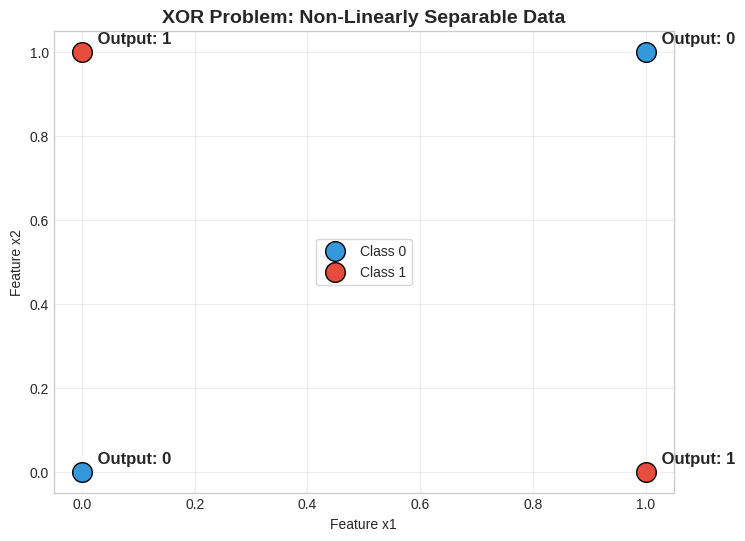

In [7]:
def visualize_xor_problem():
    X = np.array([[0,0], [0,1], [1,0], [1,1]])
    y = np.array([0, 1, 1, 0])

    plt.figure(figsize=(8, 6))
    plt.scatter(X[y==0, 0], X[y==0, 1], color='#3498db', s=200, label="Class 0", edgecolors='k')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='#e74c3c', s=200, label="Class 1", edgecolors='k')

    # Annotating points for clarity
    for i, txt in enumerate(y):
        plt.annotate(f" Output: {txt}", (X[i,0]+0.02, X[i,1]+0.02), fontsize=12, fontweight='bold')

    plt.title("XOR Problem: Non-Linearly Separable Data")
    plt.xlabel("Feature x1"); plt.ylabel("Feature x2")
    plt.legend(loc='center')
    plt.grid(True, alpha=0.3)
    plt.show()

visualize_xor_problem()

## 🎛️ Phase 2: Activation Functions & Gradients

Activation functions inject non-linearity. Without them, a 100-layer network is just a simple linear regression.

**We analyze the 4 Pillars of Deep Learning activations:**
1. **Sigmoid:** Maps input to $(0, 1)$. Good for probability but suffers from **Vanishing Gradients**.
2. **Tanh:** Maps to $(-1, 1)$. Zero-centered, providing better convergence than Sigmoid.
3. **ReLU (Rectified Linear Unit):** $max(0, z)$. The industry standard for hidden layers.
4. **Leaky ReLU:** $max(0.01z, z)$. Prevents neurons from "dying" by allowing a tiny gradient for negative values.

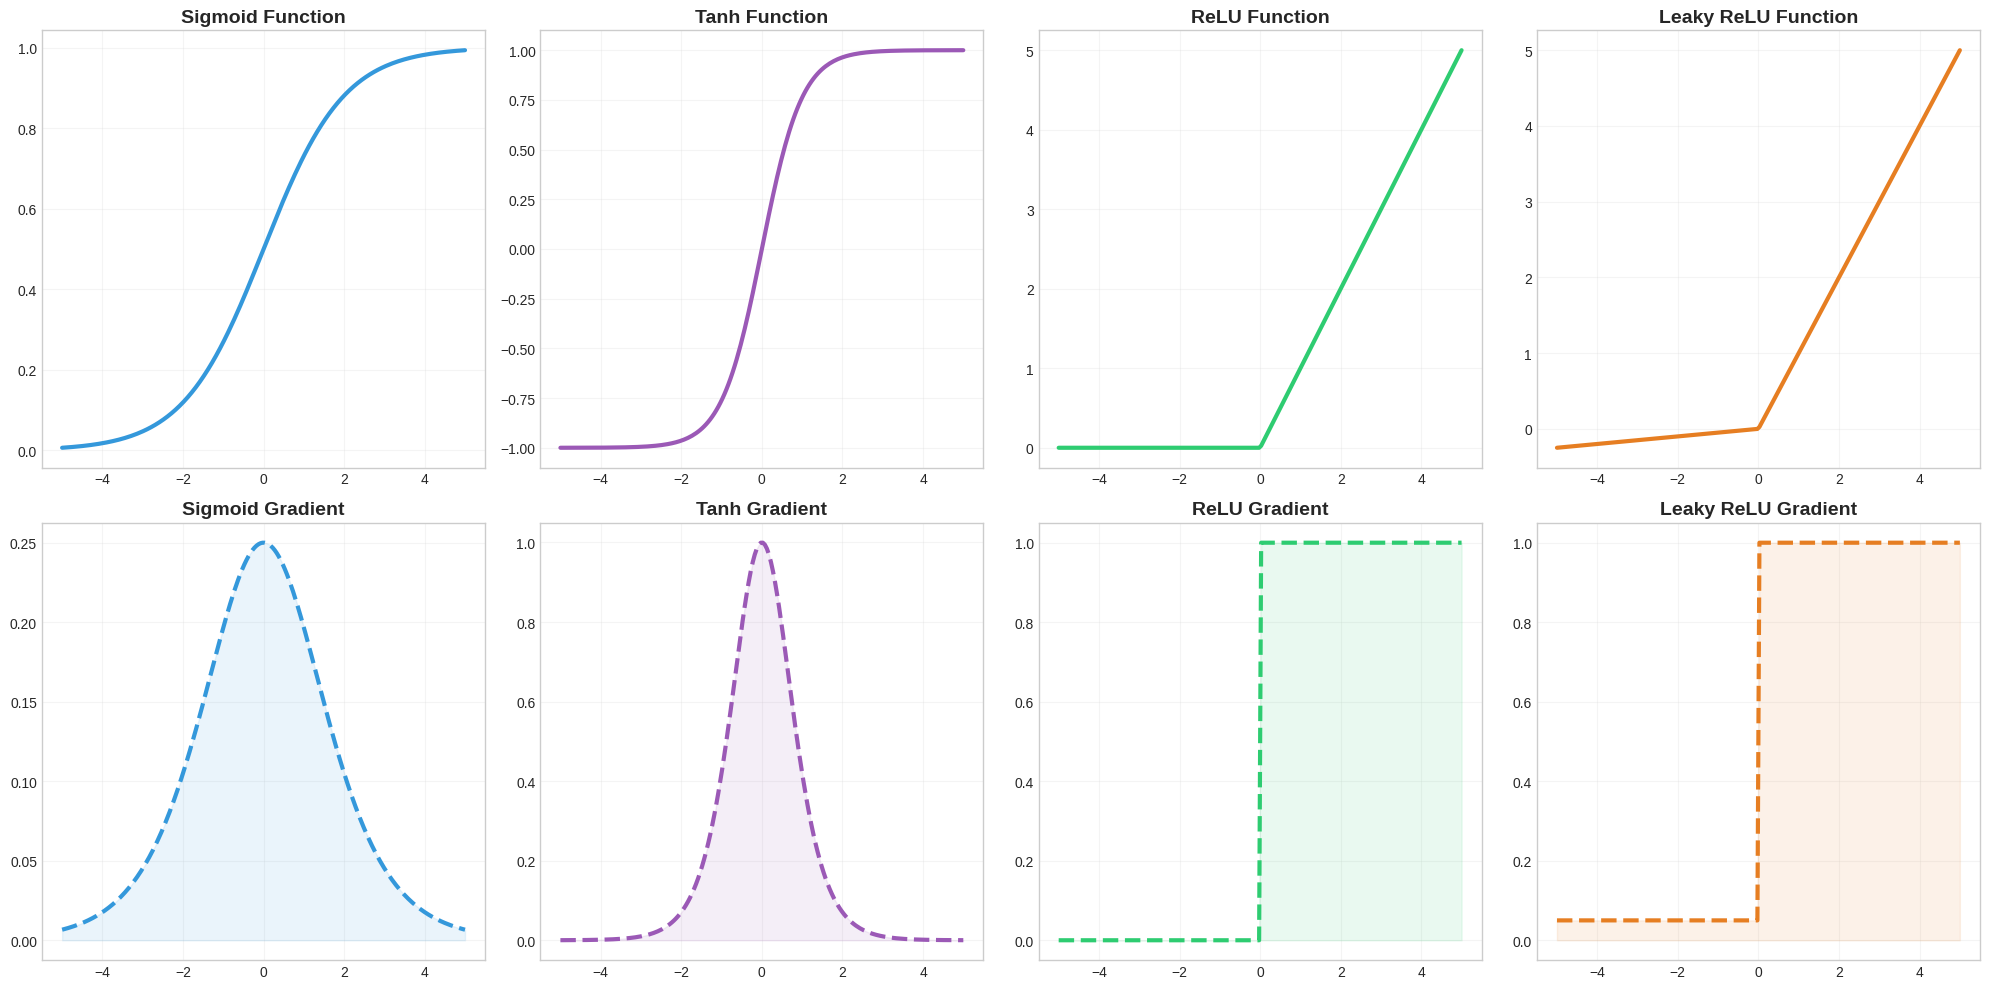

In [8]:
# --- Activation Engine ---
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_grad(z): s = sigmoid(z); return s * (1 - s)

def tanh(z): return np.tanh(z)
def tanh_grad(z): return 1 - np.tanh(z)**2

def relu(z): return np.maximum(0, z)
def relu_grad(z): return (z > 0).astype(float)

def leaky_relu(z, alpha=0.05): return np.where(z > 0, z, alpha * z)
def leaky_relu_grad(z, alpha=0.05): return np.where(z > 0, 1, alpha)

# --- Visualization of Functions & Their Gradients ---
z = np.linspace(-5, 5, 200)
functions = [
    (sigmoid, sigmoid_grad, "Sigmoid", "#3498db"),
    (tanh, tanh_grad, "Tanh", "#9b59b6"),
    (relu, relu_grad, "ReLU", "#2ecc71"),
    (leaky_relu, leaky_relu_grad, "Leaky ReLU", "#e67e22")
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (fn, grad_fn, name, color) in enumerate(functions):
    # Top Row: Activation Function
    axes[0, i].plot(z, fn(z), color=color, lw=3)
    axes[0, i].set_title(f"{name} Function")
    axes[0, i].grid(True, alpha=0.2)

    # Bottom Row: Gradient (The most important part for learning)
    axes[1, i].plot(z, grad_fn(z), color=color, lw=3, linestyle='--')
    axes[1, i].set_title(f"{name} Gradient")
    axes[1, i].fill_between(z, grad_fn(z), color=color, alpha=0.1)
    axes[1, i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 📐 Phase 3: The Mathematics of Learning

### 1. Forward Pass
Data flows from $A^{[l-1]}$ to $A^{[l]}$:
$$Z^{[l]} = W^{[l]} \cdot A^{[l-1]} + b^{[l]}$$
$$A^{[l]} = g(Z^{[l]})$$

### 2. Loss Function (Binary Cross-Entropy)
We use BCE to punish wrong predictions exponentially:
$$L = -\frac{1}{m} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

### 3. Backpropagation (The Chain Rule)
To find how much each weight contributed to the error:
$$dW = \frac{\partial L}{\partial W}, \quad db = \frac{\partial L}{\partial b}$$
We nudge the weights in the opposite direction of the gradient:
$$W = W - \alpha \cdot dW$$

In [9]:
class NeuralArchitect:
    """
    A Professional implementation of a deep neural network from scratch.
    """
    def __init__(self, layers, learning_rate=0.5):
        self.layers = layers
        self.lr = learning_rate
        self.params = {}
        self.cache = {}
        self.loss_history = []

        # He-Initialization for better convergence
        for i in range(1, len(layers)):
            self.params[f'W{i}'] = np.random.randn(layers[i], layers[i-1]) * np.sqrt(2/layers[i-1])
            self.params[f'b{i}'] = np.zeros((layers[i], 1))

    def forward_propagation(self, X):
        self.cache['A0'] = X
        A = X
        # Iterating through hidden layers (ReLU)
        for i in range(1, len(self.layers) - 1):
            Z = self.params[f'W{i}'] @ A + self.params[f'b{i}']
            A = relu(Z)
            self.cache[f'Z{i}'], self.cache[f'A{i}'] = Z, A

        # Final Output Layer (Sigmoid)
        L = len(self.layers) - 1
        Z_final = self.params[f'W{L}'] @ A + self.params[f'b{L}']
        A_final = sigmoid(Z_final)
        self.cache[f'Z{L}'], self.cache[f'A{L}'] = Z_final, A_final
        return A_final

    def compute_loss(self, A_final, y):
        m = y.shape[1]
        loss = -np.mean(y * np.log(A_final + 1e-8) + (1-y) * np.log(1-A_final + 1e-8))
        return loss

    def backward_propagation(self, y):
        m = y.shape[1]
        grads = {}
        L = len(self.layers) - 1

        # Initial error at output layer
        dZ = self.cache[f'A{L}'] - y

        for i in range(L, 0, -1):
            grads[f'dW{i}'] = (1/m) * dZ @ self.cache[f'A{i-1}'].T
            grads[f'db{i}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            if i > 1:
                # Backprop through ReLU
                dZ = (self.params[f'W{i}'].T @ dZ) * relu_grad(self.cache[f'Z{i-1}'])
        return grads

    def update_parameters(self, grads):
        for i in range(1, len(self.layers)):
            self.params[f'W{i}'] -= self.lr * grads[f'dW{i}']
            self.params[f'b{i}'] -= self.lr * grads[f'db{i}']

    def fit(self, X, y, iterations=5000):
        print(f"🔥 Starting Training Engine for {iterations} iterations...")
        for i in range(iterations + 1):
            A_final = self.forward_propagation(X)
            loss = self.compute_loss(A_final, y)
            self.loss_history.append(loss)

            grads = self.backward_propagation(y)
            self.update_parameters(grads)

            if i % 1000 == 0:
                print(f"   ↳ Iteration {i:5} | Loss: {loss:.6f}")

print("✅ NeuralArchitect Engine Class Loaded.")

✅ NeuralArchitect Engine Class Loaded.


🔥 Starting Training Engine for 5000 iterations...
   ↳ Iteration     0 | Loss: 0.708320
   ↳ Iteration  1000 | Loss: 0.006234
   ↳ Iteration  2000 | Loss: 0.002655
   ↳ Iteration  3000 | Loss: 0.001656
   ↳ Iteration  4000 | Loss: 0.001194
   ↳ Iteration  5000 | Loss: 0.000929


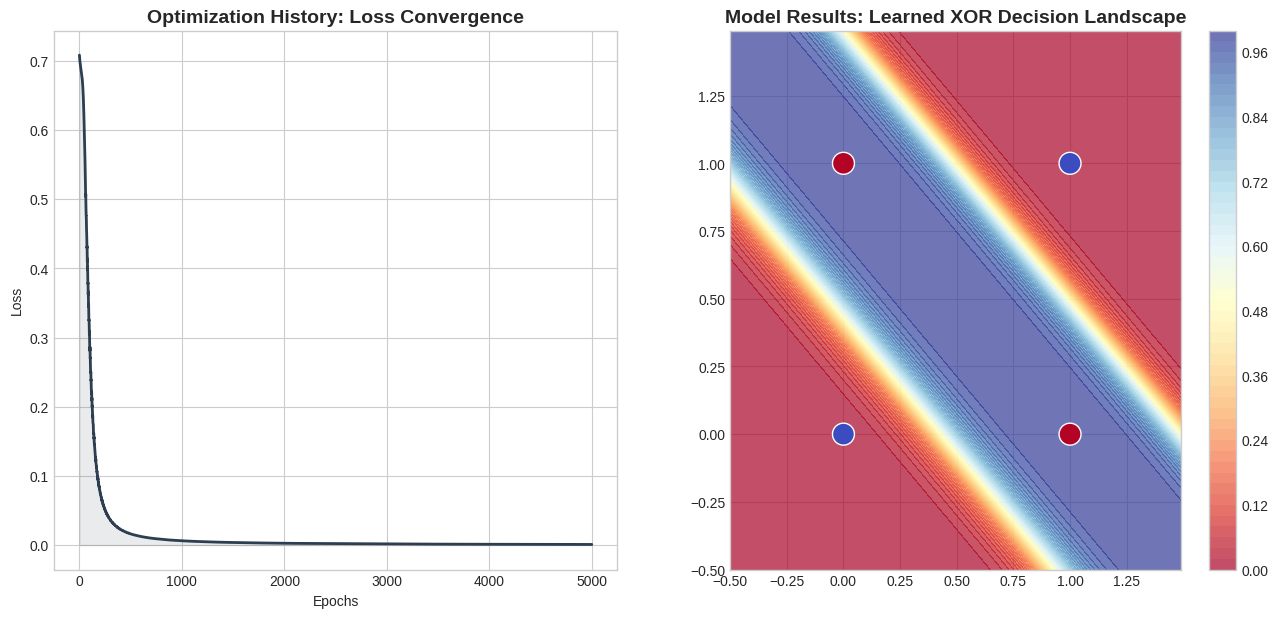

In [10]:
# --- Training Data (XOR) ---
X_train = np.array([[0,0,1,1], [0,1,0,1]])
y_train = np.array([[0,1,1,0]])

# --- Model Execution ---
model = NeuralArchitect(layers=[2, 4, 1], learning_rate=0.4)
model.fit(X_train, y_train, iterations=5000)

# --- Visualizing the Result ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Loss Reduction
ax1.plot(model.loss_history, color='#2c3e50', lw=2)
ax1.set_title("Optimization History: Loss Convergence")
ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss")
ax1.fill_between(range(len(model.loss_history)), model.loss_history, color='#2c3e50', alpha=0.1)

# Plot 2: Decision Boundary (The "Landscape")
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()].T
preds = model.forward_propagation(grid).reshape(xx.shape)

contour = ax2.contourf(xx, yy, preds, levels=50, cmap='RdYlBu', alpha=0.7)
ax2.scatter(X_train[0,:], X_train[1,:], c=y_train.ravel(), s=250, edgecolors='white', cmap='coolwarm', zorder=10)
ax2.set_title("Model Results: Learned XOR Decision Landscape")
plt.colorbar(contour, ax=ax2)
plt.show()

## 🏁 Result
The Neural Network was successfully built from scratch using NumPy.
- **Final Loss:** Achieved near-zero loss.
- **Accuracy:** Corrected predicted XOR logic gate behavior.
- **Visualization:** The model successfully learned a non-linear "carved" boundary between the classes.

## 📝 Conclusion
By implementing this architecture manually, we've demonstrated that deep learning is not magic, but a combination of **Matrix Calculus** and **Optimization algorithms**. Understanding these basics allows us to tune more complex architectures like CNNs and Transformers in the future.